# 04. 相図と安定性 — 固定点・線形化・分類

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture 〜 5. Definition |
| Applied | 6. Computation 〜 9. Application |
| Advanced | 11. Advanced Notes |

## 1. Big Picture

自励系 $d\mathbf{x}/dt = \mathbf{f}(\mathbf{x})$ では、時刻に依らず各点に速度ベクトルが定まります。
これを平面に描いたものが **相図 (phase portrait)**。解は時間軸を消して **軌道(オービット)** として見えます。
relevant な情報は **固定点(平衡点)とその安定性** に凝縮されます。

## 2. Problem / 3. Intuition / 5. Definition — 固定点を分類する

$\mathbf{f}(\mathbf{x}^\*)=\mathbf{0}$ となる点が **固定点**。その近くで $\mathbf{f}$ を線形化すると、
ヤコビ行列 $J = D\mathbf{f}(\mathbf{x}^\*)$ の固有値が局所的な振る舞いを決めます。

- 実・同符号負 → **stable node (sink)**、実・同符号正 → **unstable node (source)**
- 実・異符号 → **saddle**
- 複素・実部負 → **stable spiral**、実部正 → **unstable spiral**、実部 0 → **center**

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import ode_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "ode_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from ode_book import systems, solvers, plotting, datasets

## 4. Visualization / 6. Computation — 5 つの典型を一望する (Applied)

線形系 $d\mathbf{x}/dt = A\mathbf{x}$ の相図を、行列 $A$ を変えて並べます。
`systems.classify_fixed_point` が固有値から型を自動判定します。

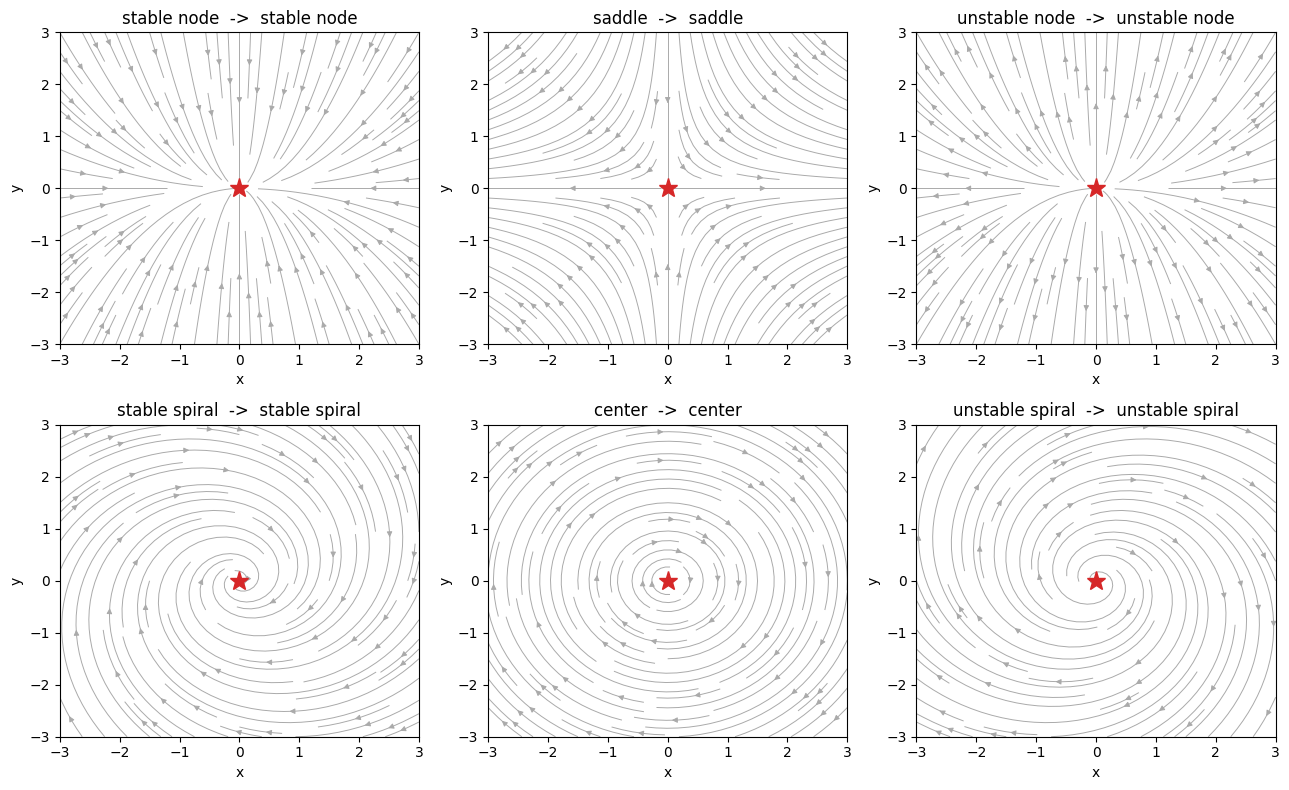

In [3]:
import numpy as np

# The canonical 2-D linear phase portraits, auto-classified from eigenvalues.
mats = {
    "stable node":     [[-1.0, 0.0], [0.0, -2.0]],
    "saddle":          [[1.0, 0.0], [0.0, -1.0]],
    "unstable node":   [[1.0, 0.0], [0.0, 2.0]],
    "stable spiral":   [[-0.3, 1.0], [-1.0, -0.3]],
    "center":          [[0.0, 1.0], [-1.0, 0.0]],
    "unstable spiral": [[0.3, 1.0], [-1.0, 0.3]],
}
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (name, A) in zip(axes.ravel(), mats.items()):
    A = np.array(A)
    f = systems.linear_system(A)
    plotting.phase_portrait(f, (-3, 3), (-3, 3), fixed_points=[(0, 0)], ax=ax)
    kind = systems.classify_fixed_point(A)
    ax.set_title(f"{name}  ->  {kind}")
fig.tight_layout()
plt.show()

### trace-determinant 図 — 1 枚で型が読める

2×2 の線形系の型は、**トレース $p=\mathrm{tr}(A)$ と行列式 $q=\det(A)$** だけで決まります。
$q<0$ なら saddle、$q>0$ では判別式 $p^2-4q$ の符号で node/spiral が分かれ($q=p^2/4$ の放物線が境界)、
$p<0$ で安定・$p>0$ で不安定。上の 5 例を $(p,q)$ 平面に置くと、領域と一対一で対応します。

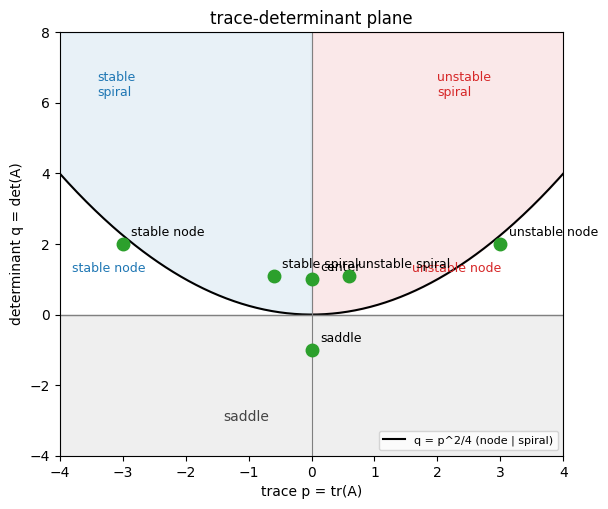

In [4]:
# Every 2x2 type at a glance: place the example matrices on the (trace, det) plane.
ax = plotting.trace_determinant_diagram(list(mats.values()), labels=list(mats.keys()))
plt.show()

## 7. Invariant / 8. Failure Mode — 線形化が効かないとき

線形化は **固有値の実部がゼロでない(双曲型)** 固定点でのみ確実です(Hartman–Grobman)。
center のように実部 0 のときは、非線形項が安定/不安定を左右し、線形化だけでは判定できません。

## 9. Application — ヌルクラインと非線形系

**ヌルクライン** は $\dot{x}=0$ や $\dot{y}=0$ となる曲線。その交点が固定点で、
ヌルクラインは平面を「どちらへ流れるか」の領域に分けます。
競合 2 種モデル $\dot{x}=x(3-x-2y),\ \dot{y}=y(2-x-y)$ で描いてみます。

fixed point (0, 0): type = unstable node
fixed point (3, 0): type = stable node
fixed point (0, 2): type = stable node
fixed point (1, 1): type = saddle


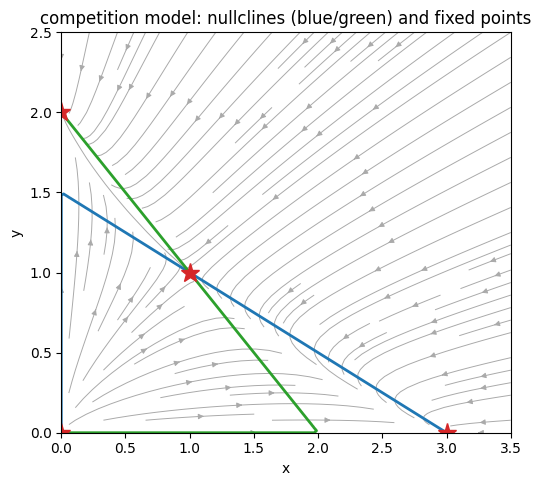

In [5]:
import numpy as np

# Nullclines (dx/dt=0 in blue, dy/dt=0 in green) and fixed points of a competition model.
def f(t, s):
    x, y = s
    return np.array([x * (3 - x - 2 * y), y * (2 - x - y)])

ax = plotting.phase_portrait(f, (0, 3.5), (0, 2.5), n=24)
xs = np.linspace(0, 3.5, 200)
ys = np.linspace(0, 2.5, 200)
X, Y = np.meshgrid(xs, ys)
DX = X * (3 - X - 2 * Y)
DY = Y * (2 - X - Y)
ax.contour(X, Y, DX, levels=[0], colors="#1f77b4", linewidths=2)
ax.contour(X, Y, DY, levels=[0], colors="#2ca02c", linewidths=2)
for fp in [(0, 0), (3, 0), (0, 2), (1, 1)]:
    ax.plot(*fp, "*", color="#d62728", ms=14)
    print(f"fixed point {fp}: type =", systems.classify_fixed_point(systems.jacobian(f, fp)))
ax.set_title("competition model: nullclines (blue/green) and fixed points")
plt.show()

## Exercises

1. $A = \begin{pmatrix} 2 & 1 \\ 1 & 2 \end{pmatrix}$ の固定点の型を、固有値を手計算して判定し、`classify_fixed_point` と一致させよ。
2. 減衰振動子 $(\gamma>0)$ の原点が stable spiral になることを、ヤコビ行列の固有値から示せ。
3. 上の競合モデルで内部固定点 $(1,1)$ が saddle になることを確かめ、生態学的な意味(共存できない)を述べよ。

## Advanced Notes

- **Hartman–Grobman 定理**: 双曲型固定点の近くでは、非線形系は線形化系と位相共役(定性的に同じ)。
- **trace–determinant 図**: 2×2 では $\mathrm{tr}\,A$ と $\det A$ の位置だけで型が決まる。判別式 $(\mathrm{tr})^2 - 4\det$ の符号が node/spiral を分ける。
- **Lyapunov 関数**: 線形化で決まらない場合でも、適切なエネルギー様関数 $V$ が減少すれば漸近安定を示せる。
- **Poincaré–Bendixson 定理**: 平面の有界軌道は、固定点か **閉軌道(リミットサイクル)** に収束する。平面ではカオスは起きない(→ 3 次元が必要、05 章)。